#📌 Extracción

1. Vamos a cargar la data de la API, cargue dicho archivo Json a mi repositorio previamente. También crearemos un Data Frame:

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/JuanCanchi19/challenger-2-alura-store-data-sciece/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

2.  Exploraremos las columnas del dataset y verificaremos sus tipos de datos:

In [7]:
df.columns



Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


3. Consultamos el diccionario para obtener mayor información de la data:

In [9]:
diccionario_url = "https://raw.githubusercontent.com/JuanCanchi19/challenger-2-alura-store-data-sciece/main/TelecomX_diccionario.md"

import requests

diccionario = requests.get(diccionario_url).text
print(diccionario)

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: t

Extra: Normalizamos algunas columnas:

In [11]:
customer_df = pd.json_normalize(df["customer"])
phone_df = pd.json_normalize(df["phone"])
internet_df = pd.json_normalize(df["internet"])
account_df = pd.json_normalize(df["account"])

df_exp = pd.concat([df[["customerID","Churn"]], customer_df, phone_df, internet_df, account_df], axis=1)

4. ¿Cuáles son las columnas relevantes para analizar la evasión?

Las variables más útiles según el diccionario son:

Churn ----- variable objetivo (si el cliente se fue o no)

tenure ----- tiempo que el cliente lleva con la empresa

Contract ----- tipo de contrato

Charges.Monthly ----- gasto mensual

Charges.Total ----- gasto total

InternetService ------ tipo de servicio de internet

TechSupport ----- soporte técnico

OnlineSecurity ----- seguridad en línea

PaymentMethod ----- método de pago

PaperlessBilling ------ facturación digital

Estas variables pueden influir directamente en la probabilidad de abandono del cliente.

Creamos un Data Frame de las más relevantes:

In [13]:
columnas_relevantes = [
    "Churn",
    "tenure",
    "Contract",
    "Charges.Monthly",
    "Charges.Total",
    "InternetService",
    "TechSupport",
    "OnlineSecurity",
    "PaymentMethod",
    "PaperlessBilling"
]


# Comprobación de incoherencias en los datos
¿Hay incoherencias en los datos?

4. Detectamos inconsistencias en categorías con los valores únicos

In [14]:
for col in columnas_relevantes:
    print(col, ":", pd.unique(df_exp[col]))

Churn : ['No' 'Yes' '']
tenure : [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
Contract : ['One year' 'Month-to-month' 'Two year']
Charges.Monthly : [65.6  59.9  73.9  ... 91.75 68.8  67.85]
Charges.Total : ['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']
InternetService : ['DSL' 'Fiber optic' 'No']
TechSupport : ['Yes' 'No' 'No internet service']
OnlineSecurity : ['No' 'Yes' 'No internet service']
PaymentMethod : ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
PaperlessBilling : ['Yes' 'No']


Encontramos: Churn = Ese '' es un valor vacío.
Charges.Total = valores como texto (object), no como número.
tenure sí está bien. Aparecen números enteros como:
Contract está limpio
InternetService está limpio
TechSupport y OnlineSecurity tienen una categoría especial 'No internet service'
PaymentMethod está consistente
PaperlessBilling está limpio

Ahora bien, para estar seguros de la información contenida en las columnas, haremos lo mismo con las variables restantes y de ser necesario notificaremos las inconsistencias:

In [15]:
# columnas que NO son parte del análisis principal
columnas_faltantes = [col for col in df_exp.columns if col not in columnas_relevantes]

# dataframe con esas columnas
df_faltantes = df_exp[columnas_faltantes]

df_faltantes.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,OnlineBackup,DeviceProtection,StreamingTV,StreamingMovies
0,0002-ORFBO,Female,0,Yes,Yes,Yes,No,Yes,No,Yes,No
1,0003-MKNFE,Male,0,No,No,Yes,Yes,No,No,No,Yes
2,0004-TLHLJ,Male,0,No,No,Yes,No,No,Yes,No,No
3,0011-IGKFF,Male,1,Yes,No,Yes,No,Yes,Yes,Yes,Yes
4,0013-EXCHZ,Female,1,Yes,No,Yes,No,No,No,Yes,No


In [16]:
for col in df_faltantes.columns:
    print(col, ":", pd.unique(df_faltantes[col]))

customerID : ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
gender : ['Female' 'Male']
SeniorCitizen : [0 1]
Partner : ['Yes' 'No']
Dependents : ['Yes' 'No']
PhoneService : ['Yes' 'No']
MultipleLines : ['No' 'Yes' 'No phone service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
StreamingTV : ['Yes' 'No' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']


Las variables restantes no presentan errores evidentes en sus categorías. Algunas incluyen la categoría especial 'No internet service' o 'No phone service', lo cual es lógico porque estos servicios adicionales dependen de que el cliente tenga contratado el servicio principal correspondiente.

# Manejo de inconsistencias

5. Corregir valores vacíos en Churn

In [17]:
df_exp["Churn"] = df_exp["Churn"].replace("", pd.NA)

6. Convertir Charges.Total a numérico

In [18]:
df_exp["Charges.Total"] = pd.to_numeric(df_exp["Charges.Total"], errors="coerce")

7. Verificar nuevamente

In [19]:
df_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


Después de aplicar las correcciones, la estructura del dataset se mantiene consistente. La variable Charges.Total fue convertida correctamente a formato numérico y los valores vacíos de Churn fueron transformados en valores nulos para su posterior tratamiento. En general, los datos están ahora en un estado adecuado para continuar con el análisis exploratorio de la evasión de clientes.

# Columna de cuentas diarias

8. Creamos la columna cuentas diarias para un posible análisis futuro

In [20]:
df_exp["Cuentas_Diarias"] = df_exp["Charges.Monthly"] / 30

df_exp[["Charges.Monthly", "Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


# Estandarización y transformación de datos
9. Hacemos la data más consistente, comprensible y adecuada para el análisis.

In [21]:
df_exp["Churn"] = df_exp["Churn"].map({"Yes": 1, "No": 0})
df_exp["Partner"] = df_exp["Partner"].map({"Yes": 1, "No": 0})
df_exp["Dependents"] = df_exp["Dependents"].map({"Yes": 1, "No": 0})
df_exp["PaperlessBilling"] = df_exp["PaperlessBilling"].map({"Yes": 1, "No": 0})

df_exp.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


9.1. Hacemos lo mismo con las restantes:

In [22]:
cols_binarias = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in cols_binarias:
    df_exp[col] = df_exp[col].replace({"Yes": 1, "No": 0})

df_exp[cols_binarias].head()

/tmp/ipykernel_319/152132221.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_exp[col] = df_exp[col].replace({"Yes": 1, "No": 0})


,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,1,0,0,1,0,1,1,0
1,1,1,0,0,0,0,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,1,1,0,1,1
4,1,0,0,0,0,1,1,0


In [23]:
df_exp.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis(L - Load & Analysis)
10. Análisis Descriptivo

In [24]:
df_exp.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.265370,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.157337
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


10.1. Incluimos variables categóricas:

In [25]:
df_exp.describe(include="all")

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267,7043.000000,7267,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.0,7267,...,7267.0,7267.0,7267.0,7267.0,7267,7267.000000,7267,7267.000000,7256.000000,7267.000000
unique,7267,NaN,2,NaN,NaN,NaN,NaN,NaN,3.0,3,...,3.0,3.0,3.0,3.0,3,NaN,4,NaN,NaN,NaN
top,9995-HOTOH,NaN,Male,NaN,NaN,NaN,NaN,NaN,0.0,Fiber optic,...,0.0,0.0,0.0,0.0,Month-to-month,NaN,Electronic check,NaN,NaN,NaN
freq,1,NaN,3675,NaN,NaN,NaN,NaN,NaN,3495.0,3198,...,3195.0,3582.0,2896.0,2870.0,4005,NaN,2445,NaN,NaN,NaN
mean,NaN,0.265370,NaN,0.162653,0.484106,0.300124,32.346498,0.902711,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.593230,NaN,64.720098,2280.634213,2.157337
std,NaN,0.441561,NaN,0.369074,0.499782,0.458343,24.571773,0.296371,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.491265,NaN,30.129572,2268.632997,1.004319
min,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,18.250000,18.800000,0.608333
25%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,9.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,35.425000,400.225000,1.180833
50%,NaN,0.000000,NaN,0.000000,0.000000,0.000000,29.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,70.300000,1391.000000,2.343333
75%,NaN,1.000000,NaN,0.000000,1.000000,1.000000,55.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,89.875000,3785.300000,2.995833


## Análisis descriptivo:

El dataset contiene 7267 registros de clientes. La tasa de evasión (Churn) es aproximadamente 26.5%, lo que indica que cerca de una cuarta parte de los clientes han cancelado el servicio.

El tiempo promedio de permanencia (tenure) es de 32 meses, con clientes que van desde 0 hasta 72 meses. En cuanto a facturación, el cargo mensual promedio (Charges.Monthly) es de 64.72, mientras que el cargo total promedio (Charges.Total) es de 2280.63, lo cual refleja una gran variabilidad en el gasto de los clientes.

La variable Cuentas_Diarias presenta un promedio de 2.16, derivado del cargo mensual, lo que permite analizar el comportamiento de facturación en una escala diaria.

En términos de características demográficas, aproximadamente 16% de los clientes son adultos mayores, cerca del 48% tienen pareja, y alrededor del 30% tienen dependientes. Además, el 59% utiliza facturación electrónica (PaperlessBilling).

11. Distribución de evasión: Crear un gráfico donde para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

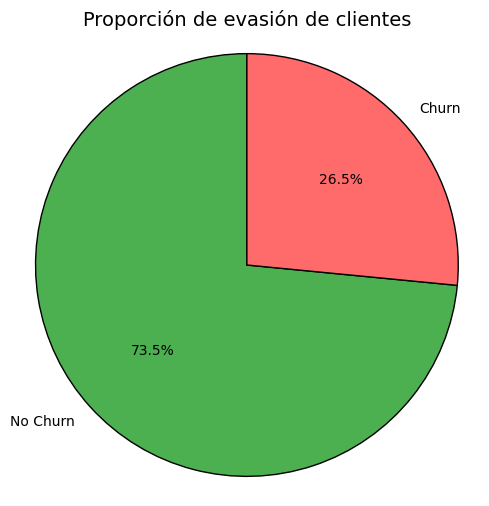

In [29]:
import matplotlib.pyplot as plt

conteo_churn = df_exp["Churn"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    conteo_churn,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#FF6B6B"],
    wedgeprops={"edgecolor": "black"}
)

plt.title("Proporción de evasión de clientes", fontsize=14)
plt.axis("equal")  # mantiene el círculo perfecto

plt.show()

12. Recuento de evasión por variables categóricas

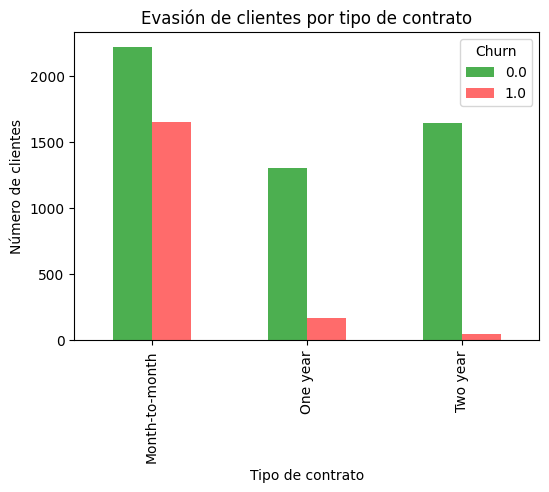

In [30]:
conteo_contrato = df_exp.groupby(["Contract", "Churn"]).size().unstack()

#conteo_contrato.plot(
#    kind="bar",
#    color=["#4CAF50", "#FF6B6B"],
#    figsize=(6,4)
#)

#plt.title("Evasión de clientes por tipo de contrato")
#plt.ylabel("Número de clientes")
#plt.xlabel("Tipo de contrato")

#plt.show()

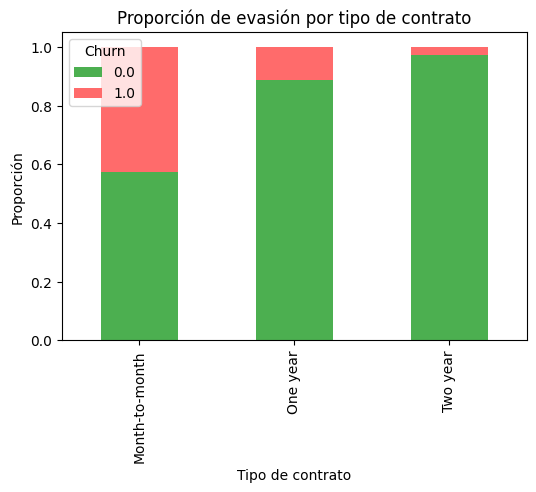

In [31]:
tabla = pd.crosstab(df_exp["Contract"], df_exp["Churn"], normalize="index")

tabla.plot(
    kind="bar",
    stacked=True,
    color=["#4CAF50", "#FF6B6B"],
    figsize=(6,4)
)

plt.title("Proporción de evasión por tipo de contrato")
plt.ylabel("Proporción")
plt.xlabel("Tipo de contrato")

plt.show()

El gráfico muestra que los clientes con contrato Month-to-month presentan la mayor proporción de evasión. En contraste, los contratos de uno y dos años muestran tasas de cancelación mucho menores. Esto sugiere que los contratos a largo plazo contribuyen significativamente a la retención de clientes.

13. Conteo de evasión por variables numéricas

Para una mejor visualización usaremos la librería seaborn

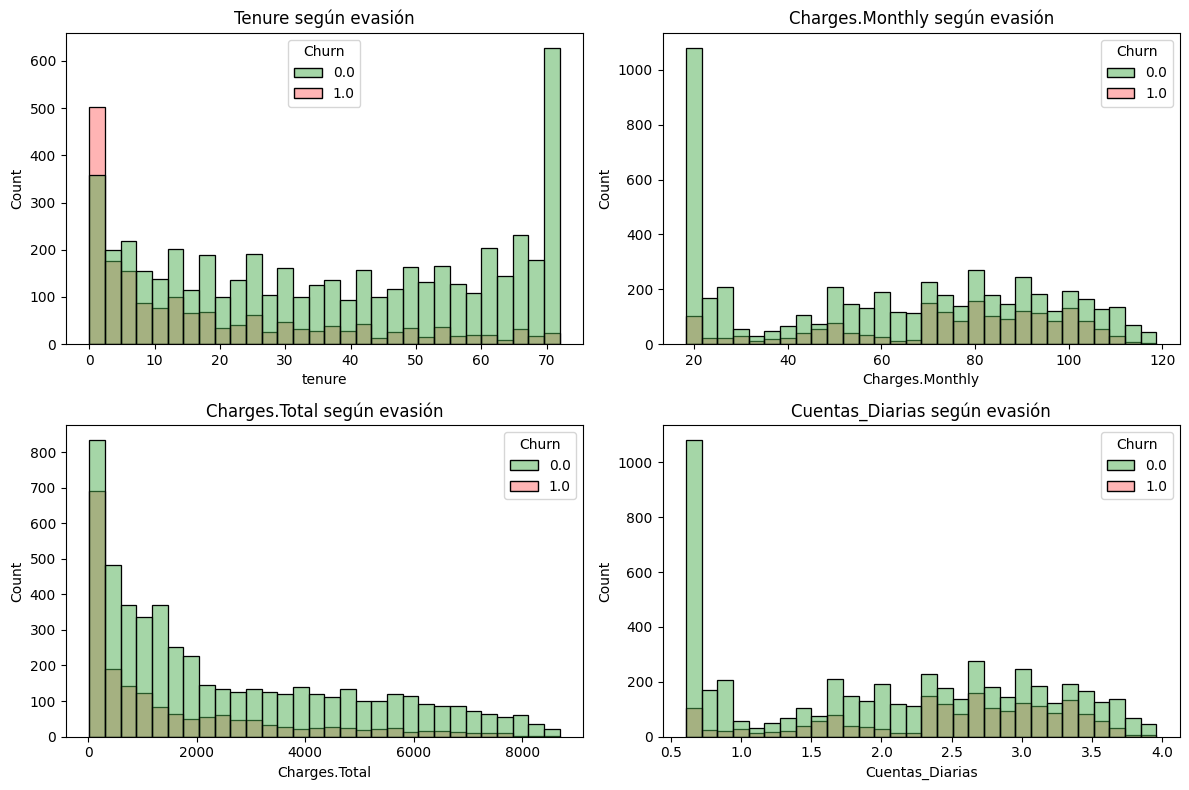

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# tenure
sns.histplot(data=df_exp, x="tenure", hue="Churn", bins=30,
             palette={0:"#4CAF50", 1:"#FF6B6B"}, ax=axes[0,0])
axes[0,0].set_title("Tenure según evasión")

# Charges.Monthly
sns.histplot(data=df_exp, x="Charges.Monthly", hue="Churn", bins=30,
             palette={0:"#4CAF50", 1:"#FF6B6B"}, ax=axes[0,1])
axes[0,1].set_title("Charges.Monthly según evasión")

# Charges.Total
sns.histplot(data=df_exp.dropna(subset=["Charges.Total"]),
             x="Charges.Total", hue="Churn", bins=30,
             palette={0:"#4CAF50", 1:"#FF6B6B"}, ax=axes[1,0])
axes[1,0].set_title("Charges.Total según evasión")

# Cuentas_Diarias
sns.histplot(data=df_exp, x="Cuentas_Diarias", hue="Churn", bins=30,
             palette={0:"#4CAF50", 1:"#FF6B6B"}, ax=axes[1,1])
axes[1,1].set_title("Cuentas_Diarias según evasión")

plt.tight_layout()
plt.show()

Para una mejor visualización usamos curvas de densidad (más suaves) con kde=True

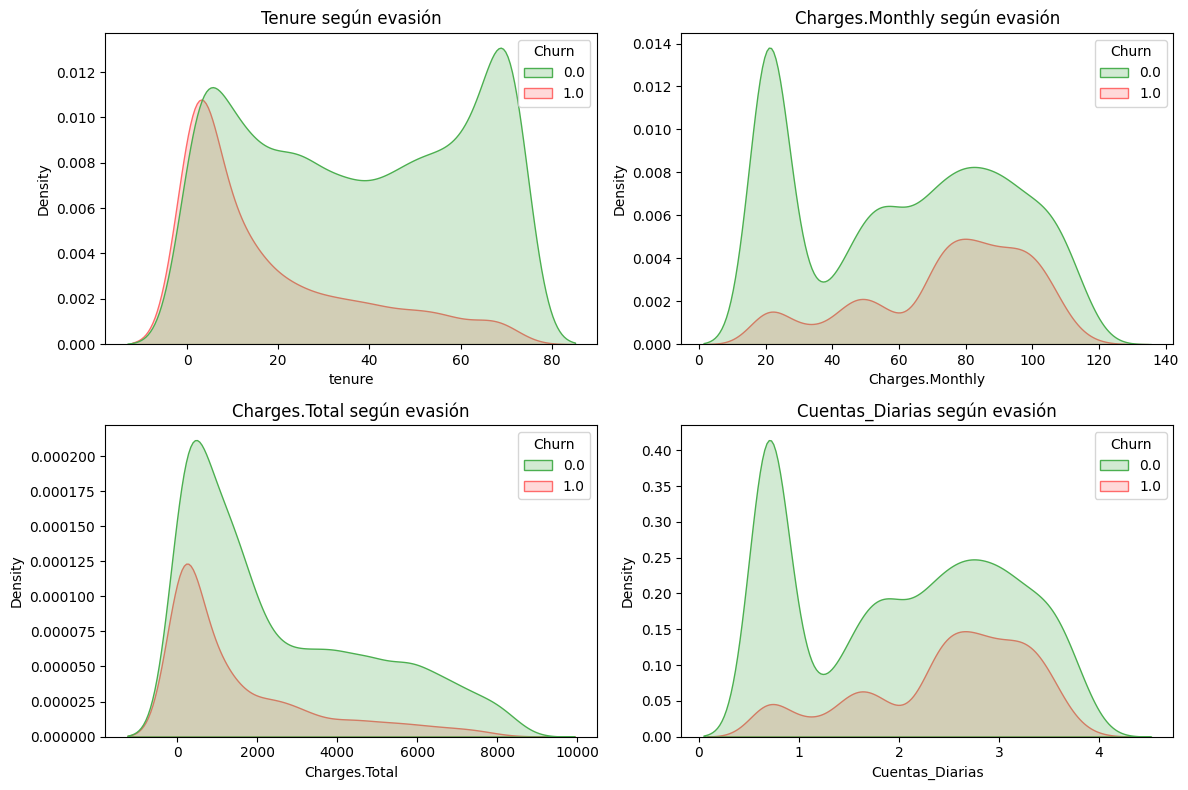

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.kdeplot(data=df_exp, x="tenure", hue="Churn",
            palette={0:"#4CAF50", 1:"#FF6B6B"}, fill=True, ax=axes[0,0])
axes[0,0].set_title("Tenure según evasión")

sns.kdeplot(data=df_exp, x="Charges.Monthly", hue="Churn",
            palette={0:"#4CAF50", 1:"#FF6B6B"}, fill=True, ax=axes[0,1])
axes[0,1].set_title("Charges.Monthly según evasión")

sns.kdeplot(data=df_exp.dropna(subset=["Charges.Total"]),
            x="Charges.Total", hue="Churn",
            palette={0:"#4CAF50", 1:"#FF6B6B"}, fill=True, ax=axes[1,0])
axes[1,0].set_title("Charges.Total según evasión")

sns.kdeplot(data=df_exp, x="Cuentas_Diarias", hue="Churn",
            palette={0:"#4CAF50", 1:"#FF6B6B"}, fill=True, ax=axes[1,1])
axes[1,1].set_title("Cuentas_Diarias según evasión")

plt.tight_layout()
plt.show()

# ¡Extra! Análisis de correlación entre variables
14. Matriz de correlación

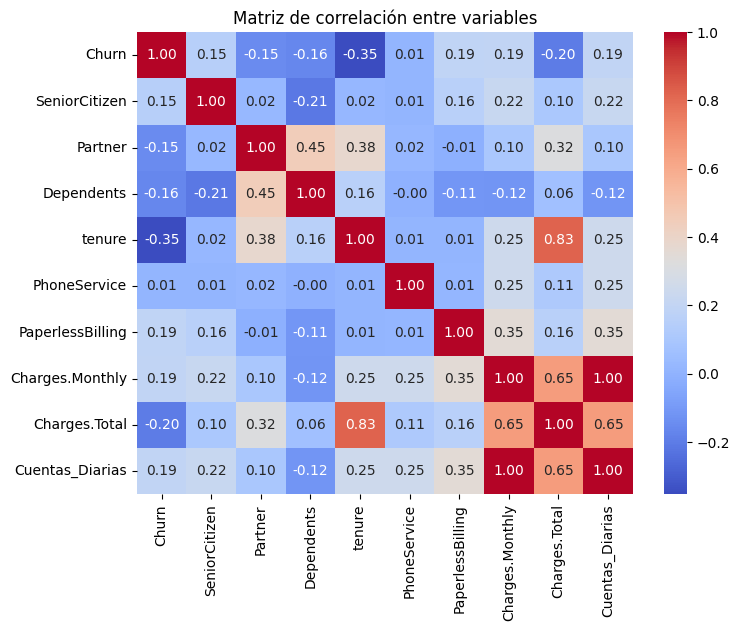

In [40]:
# variables numéricas
numericas = df_exp[[
    "Churn",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "PaperlessBilling",
    "Charges.Monthly",
    "Charges.Total",
    "Cuentas_Diarias"
]]

corr = numericas.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables")
plt.show()

15. Relación entre cuenta diaria y churn

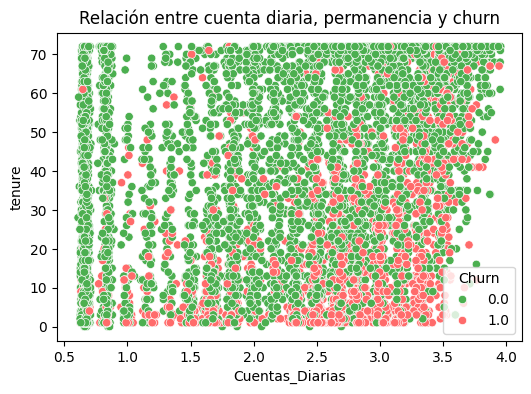

In [41]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df_exp,
    x="Cuentas_Diarias",
    y="tenure",
    hue="Churn",
    palette={0:"#4CAF50", 1:"#FF6B6B"}
)

plt.title("Relación entre cuenta diaria, permanencia y churn")
plt.show()

16. Cantidad de servicios contratados vs churn.
Identificamos un error en la data el cual se corrige previamente

/tmp/ipykernel_319/2049926147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


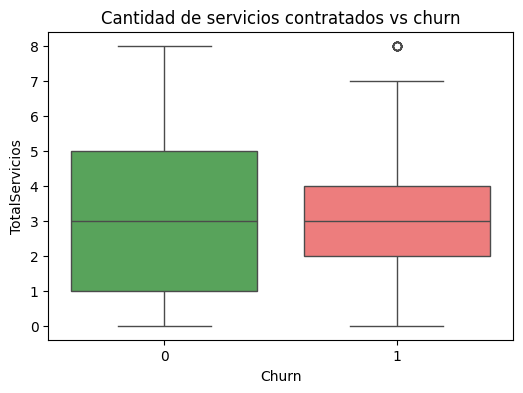

In [47]:
df_exp = df_exp.dropna(subset=["Churn"])
df_exp["Churn"] = df_exp["Churn"].astype(int)

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_exp,
    x="Churn",
    y="TotalServicios",
    palette={"0":"#4CAF50", "1":"#FF6B6B"}
)

plt.title("Cantidad de servicios contratados vs churn")
plt.show()

#📄Informe de Análisis de Evasión de Clientes (Churn)

1. Introducción

El objetivo de este análisis es comprender los factores asociados a la evasión de clientes (Churn) en la empresa TelecomX. La evasión sucede cuando un cliente decide cancelar su servicio, lo cual representa una pérdida directa de ingresos para la compañía.

A través de técnicas (EDA) buscamos identificar patrones en el comportamiento de los clientes que permitan comprender qué variables influyen en la probabilidad de abandono. Estos hallazgos pueden ayudar a la empresa a diseñar estrategias para impulsar la retención de clientes.

2. Limpieza y Tratamiento de Datos

Para preparar los datos para el análisis se realizaron los siguientes pasos:

I) Se importaron los datos desde un archivo JSON alojado en GitHub utilizando Python y Pandas.

II) Se exploró la estructura del dataset utilizando info(), columns y el diccionario de datos.

III) Se identificaron inconsistencias en algunas variables:

IV) Valores vacíos en la variable Churn.

V) La variable Charges.Total estaba almacenada como texto.

VI) Se realizaron las siguientes correcciones:

VII) Conversión de Charges.Total a tipo numérico.

VIII) Eliminación de registros con valores faltantes en Churn, ya que es la variable objetivo.

IX) Conversión de variables categóricas como Yes / No a valores binarios 1 / 0 para facilitar el análisis.

X) Se creó una nueva variable llamada Cuentas_Diarias, calculada a partir de la facturación mensual.

XII) Se generó una variable adicional llamada TotalServicios, que contabiliza el número de servicios contratados por cada cliente.

Estas transformaciones permitieron obtener un dataset limpio y adecuado para el análisis.

3. Análisis Exploratorio de Datos

Se realizaron diferentes análisis descriptivos y visualizaciones para identificar patrones asociados al churn.

Distribución de Churn

El análisis mostró que aproximadamente:

a) 73.5% de los clientes permanecen en la empresa

b) 26.5% de los clientes abandonan el servicio

Esto indica que aunque la mayoría de clientes permanece, existe una proporción significativa de cancelaciones.

Churn según tipo de contrato

Uno de los hallazgos más importantes fue la relación entre el tipo de contrato y la evasión.

Los clientes con contratos Month-to-month (mensuales) presentan una tasa de abandono considerablemente mayor que aquellos con contratos de uno o dos años.

Esto sugiere que los contratos de largo plazo contribuyen significativamente a la retención de clientes.

Relación entre tiempo de permanencia y churn

El análisis de la variable tenure (meses de permanencia) mostró que:

I) Los clientes con menor tiempo en la empresa presentan mayor probabilidad de abandonar.

II) A medida que aumenta el tiempo de permanencia, la probabilidad de churn disminuye.

Esto indica que los primeros meses del cliente son críticos para su retención.

Relación entre facturación y churn

Las variables Charges.Monthly, Charges.Total y Cuentas_Diarias mostraron una relación moderada con el churn.

En general:

Clientes con facturación mensual más alta tienden a presentar una mayor probabilidad de abandono.

Esto podría estar relacionado con la percepción de costo o valor del servicio

Correlación entre variables

El análisis de la matriz de correlación permitió identificar relaciones importantes:

a) tenure y Charges.Total presentan una fuerte correlación positiva.

b) tenure y churn presentan una correlación negativa, lo que indica que clientes más antiguos tienden a permanecer.

c) Variables como PaperlessBilling y Charges.Monthly presentan una correlación moderada con el churn.

Número de servicios contratados

Se analizó la relación entre el número de servicios contratados y la evasión.

Los resultados indican que:

I) Los clientes que abandonan suelen tener menos servicios contratados.

II) Los clientes con mayor número de servicios tienden a permanecer más tiempo.

Esto sugiere que ofrecer paquetes o servicios adicionales podría aumentar la fidelización.

4. Conclusiones e Insights

A partir del análisis realizado se identificaron varios factores asociados a la evasión de clientes:

Los contratos mensuales presentan la mayor tasa de churn.

Los clientes con menor tiempo en la empresa tienen mayor probabilidad de abandonar.

Los clientes con facturación mensual más alta muestran una tendencia mayor a cancelar el servicio.

Los clientes con menos servicios contratados presentan mayor riesgo de evasión.

Los contratos de largo plazo y la diversificación de servicios parecen contribuir a la retención.

Estos resultados permiten comprender mejor el comportamiento de los clientes y los factores que influyen en su decisión de abandonar el servicio.

5. Recomendaciones

Con base en los hallazgos del análisis, se proponen las siguientes recomendaciones estratégicas:

Incentivar contratos de largo plazo mediante descuentos o beneficios adicionales.

Implementar estrategias de retención temprana, enfocadas en clientes nuevos durante los primeros meses.

Diseñar paquetes de servicios combinados para aumentar el número de servicios contratados por cliente.

Analizar la estructura de precios para clientes con facturación elevada, con el fin de reducir posibles percepciones de alto costo.

Desarrollar campañas de fidelización dirigidas a clientes con mayor riesgo de abandono.

Estas acciones podrían ayudar a reducir la tasa de churn y mejorar la estabilidad de ingresos de la empresa.